In [1]:
import torch
import torch.nn as nn
import json
import matplotlib.pyplot as plt
from src.data import get_dataloaders
from src.model import CustomQAT_LSTM
from src.engine import train_model

import copy
from IPython.display import clear_output
from src.engine import evaluate 

import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from IPython.display import display
import os
import torch.ao.quantization as tq
from sklearn.metrics import roc_auc_score
import torch.nn.utils.parametrize as parametrize


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [2]:
BATCH_SIZE = 128
MAX_LEN = 256
EPOCHS = 10
LR = 0.001

In [3]:
global_histories = {}

In [4]:
train_loader, val_loader, test_loader, vocab_size = get_dataloaders(
    batch_size=BATCH_SIZE, 
    max_len=MAX_LEN
)

Загрузка датасета Yelp Polarity


Построение словаря...
Размер словаря: 20000 токенов.


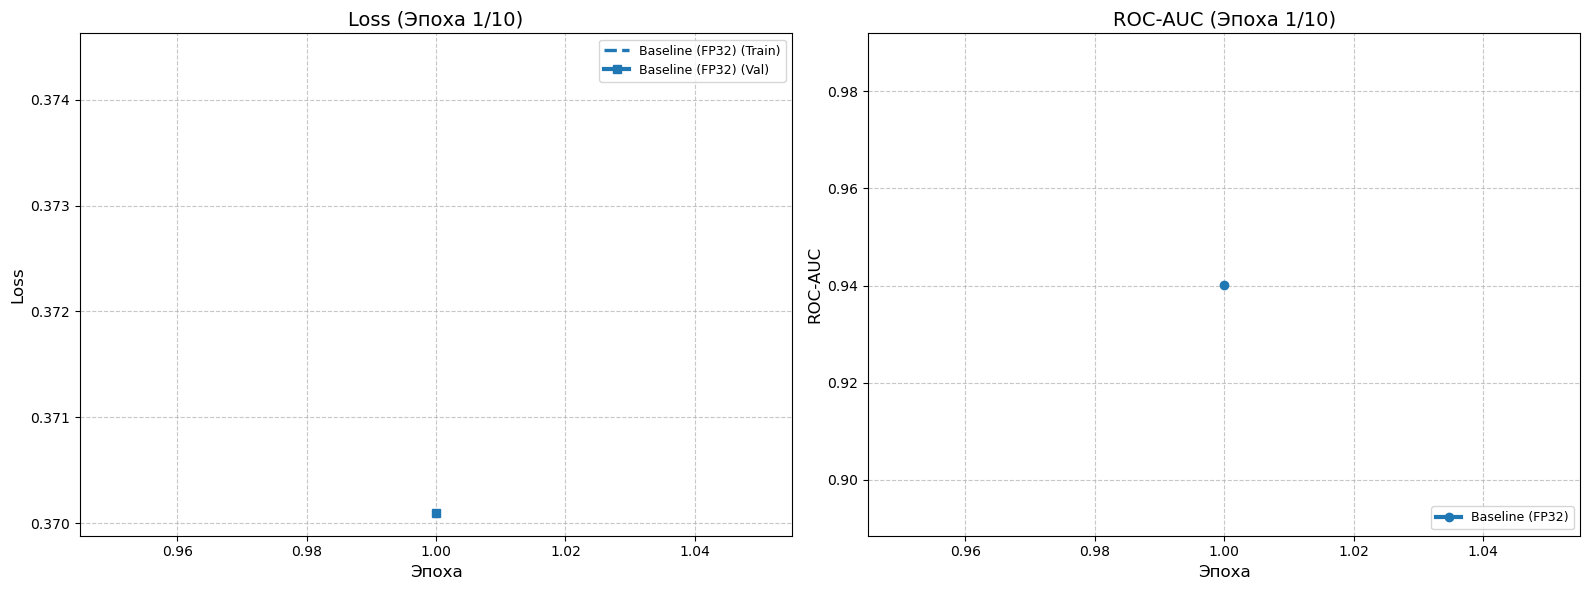

In [ ]:
print("Обучение базовой модели (FP32)")

dropout = 0.5
wd = 0.00001

print(f"Используем параметры: LR={LR:.5f}, Dropout={dropout:.2f}, Weight Decay={wd:.6f}")

global_histories = {} 

model_fp32 = CustomQAT_LSTM(
    vocab_size=vocab_size, 
    quantizer_type='none',
    dropout=dropout 
).to(device)

history_fp32 = train_model(
    model_fp32, train_loader, val_loader, 
    epochs=EPOCHS, 
    lr=LR, 
    weight_decay=wd,
    device=device, 
    method_name="Baseline (FP32)", 
    all_histories=global_histories
)

torch.save(model_fp32.state_dict(), 'results/lstm_fp32_best.pt')

In [ ]:
print("Обучение LSQ")

lsq_variants = [
    {'name': 'LSQ (Mean)',  'lr': LR, 'quant_lr_multiplier': 1.0, 'init_mode': 'mean', 'epochs': EPOCHS},
    {'name': 'LSQ (Mult=10x, Mean)', 'lr': LR, 'quant_lr_multiplier': 10.0, 'init_mode': 'mean', 'epochs': EPOCHS},
    {'name': 'LSQ (Mult=10x, MinMax)', 'lr': LR, 'quant_lr_multiplier': 10.0, 'init_mode': 'min_max', 'epochs': EPOCHS}
]

local_histories_lsq = {} 
best_auc = 0.0
best_variant_name = ""
best_history = None
best_model_state = None

for var in lsq_variants:
    print(f"Обучение: {var['name']}")
    
    model_lsq = CustomQAT_LSTM(
        vocab_size=vocab_size, quantizer_type='lsq', bit_width=8, init_mode=var['init_mode']
    ).to(device)
    
    history = train_model(
        model_lsq, train_loader, val_loader, epochs=var['epochs'], lr=var['lr'], 
        quant_lr_multiplier=var['quant_lr_multiplier'], device=device, 
        method_name=var['name'], all_histories=local_histories_lsq 
    )
    
    max_auc = max(history['val_auc']) 
    if max_auc > best_auc:
        best_auc = max_auc
        best_variant_name = var['name']
        best_history = history
        best_model_state = copy.deepcopy(model_lsq.state_dict())

clear_output(wait=True)
print(f"Лучший вариант LSQ: {best_variant_name} с ROC-AUC = {best_auc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10.colors

for i, (name, hist) in enumerate(local_histories_lsq.items()):
    c = colors[i % len(colors)]
    epochs = range(1, len(hist['val_loss']) + 1) # Ось X от 1
    
    ax1.plot(epochs, hist['train_loss'], label=f'{name} (Train)', color=c, linestyle='--', alpha=0.5)
    ax1.plot(epochs, hist['val_loss'], label=f'{name} (Val)', color=c, marker='o', linewidth=2)
    ax2.plot(epochs, hist['val_auc'], label=name, color=c, marker='s', linewidth=2)

ax1.set(title='LSQ: Сравнение Loss', xlabel='Эпоха', ylabel='Loss')
ax1.grid(True, linestyle='--', alpha=0.7); ax1.legend(fontsize=9)

ax2.set(title='LSQ: Сравнение Validation ROC-AUC', xlabel='Эпоха', ylabel='ROC-AUC')
ax2.grid(True, linestyle='--', alpha=0.7); ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()

torch.save(best_model_state, 'results/lstm_lsq_best.pt')
global_histories['QAT: LSQ'] = best_history

In [ ]:
print("Обучение PACT")

pact_variants = [
    {'name': 'PACT (Alpha=1.0)',  'lr': LR, 'quant_lr_multiplier': 1.0,  'init_alpha': 1.0, 'epochs': EPOCHS},
    {'name': 'PACT (Alpha=3.0)',  'lr': LR, 'quant_lr_multiplier': 1.0,  'init_alpha': 3.0, 'epochs': EPOCHS},
    {'name': 'PACT (Alpha=6.0)', 'lr': LR, 'quant_lr_multiplier': 1.0, 'init_alpha': 6.0, 'epochs': EPOCHS}
]

local_histories_pact = {} 
best_auc = 0.0
best_variant_name = ""
best_history = None
best_model_state = None

for var in pact_variants:
    print(f"Обучение варианта: {var['name']}")
    
    model_pact = CustomQAT_LSTM(
        vocab_size=vocab_size, 
        quantizer_type='pact', 
        bit_width=8,
        init_alpha=var['init_alpha']
    ).to(device)
    
    history = train_model(
        model_pact, train_loader, val_loader, 
        epochs=var['epochs'], 
        lr=var['lr'], 
        quant_lr_multiplier=var['quant_lr_multiplier'], 
        device=device, 
        method_name=var['name'], 
        all_histories=local_histories_pact 
    )
    
    max_auc = max(history['val_auc']) 
    if max_auc > best_auc:
        best_auc = max_auc
        best_variant_name = var['name']
        best_history = history
        best_model_state = copy.deepcopy(model_pact.state_dict())

clear_output(wait=True)
print(f"Лучший вариант PACT: {best_variant_name} с ROC-AUC = {best_auc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10.colors

for i, (name, hist) in enumerate(local_histories_pact.items()):
    c = colors[i % len(colors)]
    ax1.plot(hist['train_loss'], label=f'{name} (Train)', color=c, linestyle='--', alpha=0.5)
    ax1.plot(hist['val_loss'], label=f'{name} (Val)', color=c, marker='o', linewidth=2)
    ax2.plot(hist['val_auc'], label=name, color=c, marker='s', linewidth=2)

ax1.set_title('PACT: Сравнение Loss', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7); ax1.legend(fontsize=9)
ax2.set_title('PACT: Сравнение Validation ROC-AUC', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

torch.save(best_model_state, 'results/lstm_pact_best.pt')
global_histories['QAT: PACT'] = best_history

In [ ]:
print("Обучение APoT")

apot_variants = [
    {'name': 'APoT (m=2)', 'lr': LR, 'quant_lr_multiplier': 1.0, 'apot_m': 2, 'weight_norm': False, 'epochs': EPOCHS},
    {'name': 'APoT (m=4)', 'lr': LR, 'quant_lr_multiplier': 1.0, 'apot_m': 4, 'weight_norm': False, 'epochs': EPOCHS},
    {'name': 'APoT (m=4, Mult=10x)', 'lr': LR, 'quant_lr_multiplier': 10.0, 'apot_m': 4, 'weight_norm': False, 'epochs': EPOCHS}
]

local_histories_apot = {} 
best_auc = 0.0
best_variant_name = ""
best_history = None
best_model_state = None

for var in apot_variants:
    print(f"Обучение: {var['name']}")
    
    model_apot = CustomQAT_LSTM(
        vocab_size=vocab_size, quantizer_type='apot', bit_width=8, 
        apot_m=var['apot_m'], weight_norm=var['weight_norm']
    ).to(device)
    
    history = train_model(
        model_apot, train_loader, val_loader, epochs=var['epochs'], lr=var['lr'], 
        quant_lr_multiplier=var['quant_lr_multiplier'], device=device, 
        method_name=var['name'], all_histories=local_histories_apot 
    )
    
    max_auc = max(history['val_auc']) 
    if max_auc > best_auc:
        best_auc = max_auc
        best_variant_name = var['name']
        best_history = history
        best_model_state = copy.deepcopy(model_apot.state_dict())

clear_output(wait=True)
print(f"Лучший вариант APoT: {best_variant_name} с ROC-AUC = {best_auc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10.colors

for i, (name, hist) in enumerate(local_histories_apot.items()):
    c = colors[i % len(colors)]
    epochs = range(1, len(hist['val_loss']) + 1)
    
    ax1.plot(epochs, hist['train_loss'], label=f'{name} (Train)', color=c, linestyle='--', alpha=0.5)
    ax1.plot(epochs, hist['val_loss'], label=f'{name} (Val)', color=c, marker='o', linewidth=2)
    ax2.plot(epochs, hist['val_auc'], label=name, color=c, marker='s', linewidth=2)

ax1.set(title='APoT: Сравнение Loss', xlabel='Эпоха', ylabel='Loss')
ax1.grid(True, linestyle='--', alpha=0.7); ax1.legend(fontsize=9)

ax2.set(title='APoT: Сравнение Validation ROC-AUC', xlabel='Эпоха', ylabel='ROC-AUC')
ax2.grid(True, linestyle='--', alpha=0.7); ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()

torch.save(best_model_state, 'results/lstm_apot_best.pt')
global_histories['QAT: APoT'] = best_history

In [ ]:
print("Обучение AdaRound")

adaround_variants = [
    {'name': 'AdaRound (Lambda=0.01)',  'lr': LR, 'quant_lr_multiplier': 1.0, 'reg_lambda': 0.01,  'epochs': EPOCHS},
    {'name': 'AdaRound (Lambda=0.1)',   'lr': LR, 'quant_lr_multiplier': 1.0, 'reg_lambda': 0.1,   'epochs': EPOCHS},
    {'name': 'AdaRound (Lambda=0.001)', 'lr': LR, 'quant_lr_multiplier': 1.0, 'reg_lambda': 0.001, 'epochs': EPOCHS}
]

local_histories_ada = {} 
best_auc = 0.0
best_variant_name = ""
best_history = None
best_model_state = None

for var in adaround_variants:
    print(f"Обучение: {var['name']}")

    model_ada = CustomQAT_LSTM(
        vocab_size=vocab_size, quantizer_type='adaround', bit_width=8, reg_lambda=var['reg_lambda']
    ).to(device)

    history = train_model(
        model_ada, train_loader, val_loader, epochs=var['epochs'], lr=var['lr'], 
        quant_lr_multiplier=var['quant_lr_multiplier'], device=device, 
        method_name=var['name'], all_histories=local_histories_ada 
    )

    max_auc = max(history['val_auc']) 
    if max_auc > best_auc:
        best_auc = max_auc
        best_variant_name = var['name']
        best_history = history
        best_model_state = copy.deepcopy(model_ada.state_dict())

clear_output(wait=True)
print(f"Лучший вариант AdaRound: {best_variant_name} с ROC-AUC = {best_auc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10.colors

for i, (name, hist) in enumerate(local_histories_ada.items()):
    c = colors[i % len(colors)]
    epochs = range(1, len(hist['val_loss']) + 1)
    
    ax1.plot(epochs, hist['train_loss'], label=f'{name} (Train)', color=c, linestyle='--', alpha=0.5)
    ax1.plot(epochs, hist['val_loss'], label=f'{name} (Val)', color=c, marker='o', linewidth=2)
    ax2.plot(epochs, hist['val_auc'], label=name, color=c, marker='s', linewidth=2)

ax1.set(title='AdaRound: Сравнение Loss', xlabel='Эпоха', ylabel='Loss')
ax1.grid(True, linestyle='--', alpha=0.7); ax1.legend(fontsize=9)

ax2.set(title='AdaRound: Сравнение Validation ROC-AUC', xlabel='Эпоха', ylabel='ROC-AUC')
ax2.grid(True, linestyle='--', alpha=0.7); ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()

torch.save(best_model_state, 'results/lstm_adaround_best.pt')
global_histories['QAT: AdaRound'] = best_history

In [ ]:
print("Обучение DSQ")

dsq_variants = [
    {'name': 'DSQ (Temp=0.1)',  'lr': LR, 'quant_lr_multiplier': 1.0, 'temperature': 0.1,  'epochs': EPOCHS},
    {'name': 'DSQ (Temp=0.05)', 'lr': LR, 'quant_lr_multiplier': 1.0, 'temperature': 0.05, 'epochs': EPOCHS},
    {'name': 'DSQ (Temp=0.1, Mult=5x)',  'lr': LR, 'quant_lr_multiplier': 5.0, 'temperature': 0.1,  'epochs': EPOCHS}
]

local_histories_dsq = {} 
best_auc = 0.0
best_variant_name = ""
best_history = None
best_model_state = None

for var in dsq_variants:
    print(f"Обучение: {var['name']}")
    
    model_dsq = CustomQAT_LSTM(
        vocab_size=vocab_size, quantizer_type='dsq', bit_width=8, temperature=var['temperature'] 
    ).to(device)
    
    history = train_model(
        model_dsq, train_loader, val_loader, epochs=var['epochs'], lr=var['lr'], 
        quant_lr_multiplier=var['quant_lr_multiplier'], device=device, 
        method_name=var['name'], all_histories=local_histories_dsq 
    )

    max_auc = max(history['val_auc']) 
    if max_auc > best_auc:
        best_auc = max_auc
        best_variant_name = var['name']
        best_history = history
        best_model_state = copy.deepcopy(model_dsq.state_dict())

clear_output(wait=True)
print(f"Лучший вариант DSQ: {best_variant_name} с ROC-AUC = {best_auc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10.colors

for i, (name, hist) in enumerate(local_histories_dsq.items()):
    c = colors[i % len(colors)]
    epochs = range(1, len(hist['val_loss']) + 1)
    
    ax1.plot(epochs, hist['train_loss'], label=f'{name} (Train)', color=c, linestyle='--', alpha=0.5)
    ax1.plot(epochs, hist['val_loss'], label=f'{name} (Val)', color=c, marker='o', linewidth=2)
    ax2.plot(epochs, hist['val_auc'], label=name, color=c, marker='s', linewidth=2)

ax1.set(title='DSQ: Сравнение Loss', xlabel='Эпоха', ylabel='Loss')
ax1.grid(True, linestyle='--', alpha=0.7); ax1.legend(fontsize=9)

ax2.set(title='DSQ: Сравнение Validation ROC-AUC', xlabel='Эпоха', ylabel='ROC-AUC')
ax2.grid(True, linestyle='--', alpha=0.7); ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()

torch.save(best_model_state, 'results/lstm_dsq_best.pt')
global_histories['QAT: DSQ'] = best_history

In [ ]:
plt.figure(figsize=(12, 7))

epochs_range = range(1, EPOCHS + 1)
colors = plt.cm.tab10.colors 

style_mapping = {
    'Baseline': {'marker': 'o', 'linewidth': 3.0, 'color': 'black', 'is_base': True},
    'LSQ':      {'marker': 's', 'linewidth': 2.0, 'is_base': False},
    'PACT':     {'marker': 'x', 'linewidth': 2.0, 'is_base': False},
    'APoT':     {'marker': 'v', 'linewidth': 2.0, 'is_base': False},
    'AdaRound': {'marker': 'D', 'linewidth': 2.0, 'is_base': False},
    'DSQ':      {'marker': '^', 'linewidth': 2.0, 'is_base': False}
}

# Список для хранения финальных результатов для печати
final_results = []

color_idx = 0
for method_name, history in global_histories.items():
    if len(history['val_auc']) == 0:
        continue
        
    current_style = {'marker': '*', 'linewidth': 1.5, 'is_base': False} 
    for key, style in style_mapping.items():
        if key.lower() in method_name.lower():
            current_style = style
            break
            
    if current_style['is_base']:
        c = current_style.get('color', 'black')
    else:
        c = colors[color_idx % len(colors)]
        color_idx += 1
        
    # Сохраняем финальную метрику
    final_results.append((method_name, history['val_auc'][-1]))
        
    plt.plot(
        epochs_range[:len(history['val_auc'])], 
        history['val_auc'], 
        label=method_name, 
        color=c, 
        marker=current_style['marker'],
        linewidth=current_style['linewidth'],
        markersize=8,
        alpha=0.85
    )

plt.title('Сравнение QAT (Метрика ROC-AUC)', fontsize=15, fontweight='bold')
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('ROC-AUC на валидации', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.tight_layout()

plt.savefig('results/roc_auc_final_comparison.png', dpi=300)
plt.show()


print(f"{'Метод квантования':<21} {'ROC-AUC':<10}")

for name, auc in sorted(final_results, key=lambda x: x[1], reverse=True):
    print(f"{name:<20} | {auc:.4f}")

In [ ]:
torch.set_num_threads(1)
device = torch.device('cpu')

def measure_model_metrics(model, dataloader, model_name="Model"):
    model = model.to(device)
    model.eval()
    
    tmp_path = f"temp_{model_name}.pt"
    torch.save(model.state_dict(), tmp_path)
    model_size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    
    x_sample, lengths_sample, _ = next(iter(dataloader))
    x_sample, lengths_sample = x_sample.to(device), lengths_sample.to(device)
    
    with torch.no_grad():
        for _ in range(10): # Warmup
            _ = model(x_sample, lengths_sample)
            
    num_iterations = 30
    start_time = time.perf_counter()
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(x_sample, lengths_sample)
    end_time = time.perf_counter()
    
    avg_latency_ms = ((end_time - start_time) / num_iterations) * 1000

    # Замер метрики ROC AUC
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x, lengths, y in dataloader:
            x, lengths, y = x.to(device), lengths.to(device), y.to(device).float()
            outputs = model(x, lengths)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            probs = torch.sigmoid(outputs)
            all_preds.extend(probs.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
            
    auc_score = roc_auc_score(all_targets, all_preds)
    
    print(f"[{model_name}] Size: {model_size_mb:.2f} MB | Latency: {avg_latency_ms:.2f} ms | AUC: {auc_score:.4f}")
    return model_size_mb, avg_latency_ms, auc_score

baseline_model = CustomQAT_LSTM(
    vocab_size=vocab_size, 
    quantizer_type='none' 
).to(device)

baseline_model.load_state_dict(torch.load('results/lstm_fp32_best.pt', map_location=device, weights_only=True))

size_fp32, lat_fp32, auc_fp32 = measure_model_metrics(baseline_model, test_loader, "Baseline (FP32)")

best_qat_method = None
best_auc_overall = 0.0

for method_name, history in global_histories.items():
    if 'FP32' in method_name or 'Baseline' in method_name:
        continue 
        
    if len(history['val_auc']) > 0:
        max_auc = max(history['val_auc'])
        if max_auc > best_auc_overall:
            best_auc_overall = max_auc
            best_qat_method = method_name

print(f"Лучшая модель: {best_qat_method}")

method_to_path = {
    'QAT: LSQ': 'results/lstm_lsq_best.pt',
    'QAT: PACT': 'results/lstm_pact_best.pt',
    'QAT: APoT': 'results/lstm_apot_best.pt',
    'QAT: AdaRound': 'results/lstm_adaround_best.pt',
    'QAT: DSQ': 'results/lstm_dsq_best.pt'
}
best_weights_path = method_to_path.get(best_qat_method)

state_dict_qat = torch.load(best_weights_path, map_location=device, weights_only=True)

best_qat_model = CustomQAT_LSTM(vocab_size=vocab_size, quantizer_type='none').to(device)
best_qat_model.load_state_dict(state_dict_qat, strict=False)

# Подменяем кастомный эмбеддинг на нативный для успешной квантизации
weights_qat = best_qat_model.embedding.weight.data
v_size, emb_dim = weights_qat.shape
standard_emb = nn.Embedding(v_size, emb_dim)
standard_emb.weight.data = weights_qat.clone()
best_qat_model.embedding = standard_emb

def remove_parametrizations(model):
    for module in model.modules():
        if hasattr(module, 'parametrizations'):
            for param_name in list(module.parametrizations.keys()):
                parametrize.remove_parametrizations(module, param_name, leave_parametrized=True)

remove_parametrizations(best_qat_model)

qconfig_spec = {
    nn.LSTM: tq.default_dynamic_qconfig,
    nn.Linear: tq.default_dynamic_qconfig,
    nn.Embedding: tq.float_qparams_weight_only_qconfig 
}

model_int8 = tq.quantize_dynamic(best_qat_model, qconfig_spec=qconfig_spec)

size_int8, lat_int8, auc_int8 = measure_model_metrics(model_int8, test_loader, f"{best_qat_method} (INT8)")


print(f"\n\nBaseline (FP32) vs {best_qat_method} (INT8)")
print(f"Ускорение:      {lat_fp32 / lat_int8:.2f}x")
print(f"Сжатие весов:   {size_fp32 / size_int8:.2f}x")
print(f"Разница AUC:    {auc_fp32 - auc_int8:.5f}")